In [ ]:
## Data Integration
## Exploratory Data Analysis
## Feature Engineering

# Objectives:

# - Integrate all cleaned datasets
# - Build master dataset
# - Analyze maintenance patterns
# - Create ML-ready features
# - Save final dataset

In [1]:
import pandas as pd    
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option(
    "display.max_columns",
    None
)

In [2]:
DATA_PATH = "../data/cleaned"

tables = {}

for file in os.listdir(DATA_PATH):

    if file.endswith(".csv"):

        table_name = file.replace(".csv","")

        tables[table_name] = pd.read_csv(
            os.path.join(DATA_PATH,file)
        )

print("Loaded Tables")

for name in tables.keys():

    print(name)

Loaded Tables
apartments
asset_failure_history
building_assets
complaint_narratives
maintenance_requests
residents
resident_feedback
service_logs
society_rules
technicians
technician_availability
technician_history


In [3]:
for name, df in tables.items():

    print("\n")
    print("="*70)

    print(name)

    print("Shape:", df.shape)



apartments
Shape: (2400, 10)


asset_failure_history
Shape: (30000, 6)


building_assets
Shape: (500, 11)


complaint_narratives
Shape: (108000, 6)


maintenance_requests
Shape: (21608, 14)


residents
Shape: (6500, 11)


resident_feedback
Shape: (11840, 7)


service_logs
Shape: (47500, 10)


society_rules
Shape: (75, 5)


technicians
Shape: (80, 8)


technician_availability
Shape: (58400, 6)


technician_history
Shape: (50000, 7)


In [4]:
apartments = tables["apartments"]

residents = tables["residents"]

maintenance_requests = tables["maintenance_requests"]

technicians = tables["technicians"]

building_assets = tables["building_assets"]

service_logs = tables["service_logs"]

resident_feedback = tables["resident_feedback"]

asset_failure_history = tables["asset_failure_history"]

technician_history = tables["technician_history"]

In [5]:
master_df = maintenance_requests.copy()

master_df.shape

(21608, 14)

In [6]:
master_df = master_df.merge(

    apartments,

    on="apartment_id",

    how="left",

    suffixes=("","_apt")
)

master_df.shape

(21608, 23)

In [8]:
master_df = master_df.merge(

    residents,

    on="resident_id",

    how="left",

    suffixes=("","_res")
)

master_df.shape

(21608, 33)

In [10]:
master_df = master_df.merge(

    technicians,

    left_on="assigned_technician_id",

    right_on="technician_id",

    how="left",

    suffixes=("","_tech")
)

master_df.shape

(21608, 41)

In [11]:
master_df = master_df.merge(

    building_assets,

    on="asset_id",

    how="left",

    suffixes=("","_asset")
)

master_df.shape

(21608, 51)

In [12]:
master_df = master_df.merge(

    service_logs,

    on="request_id",

    how="left",

    suffixes=("","_service")
)

master_df.shape

(52920, 60)

In [13]:
master_df = master_df.merge(

    resident_feedback,

    on="request_id",

    how="left",

    suffixes=("","_feedback")
)

master_df.shape

(52920, 66)

In [14]:
failure_count = (

    asset_failure_history

    .groupby("asset_id")

    .size()

    .reset_index(
        name="asset_failure_count"
    )

)

master_df = master_df.merge(

    failure_count,

    on="asset_id",

    how="left"
)

In [15]:
tech_performance = (

    technician_history

    .groupby("technician_id")

    .size()

    .reset_index(
        name="completed_jobs"
    )

)

master_df = master_df.merge(

    tech_performance,

    left_on="assigned_technician_id",

    right_on="technician_id",

    how="left"
)

In [16]:
master_df.head()

,request_id,resident_id,apartment_id,asset_id,category,subcategory,complaint_text,request_date,priority,status,assigned_technician_id,resolved_date,resolution_time_hours,dataset_version,tower_id,block_name,floor_number,unit_number,apartment_type,square_feet,occupancy_status,purchase_year,dataset_version_apt,apartment_id_res,resident_name,gender,age,occupation,phone,email,move_in_date,resident_type,dataset_version_res,technician_id_x,technician_name,specialization,experience_years,rating,joining_date,availability_status,dataset_version_tech,tower_id_asset,asset_name,asset_category,manufacturer,installation_date,warranty_end,maintenance_frequency,last_service_date,asset_status,dataset_version_asset,service_id,technician_id_service,visit_number,start_time,end_time,repair_notes,parts_used,repair_cost,dataset_version_service,feedback_id,resident_id_feedback,rating_feedback,feedback_text,sentiment_label,dataset_version_feedback,asset_failure_count,technician_id_y,completed_jobs
0,req-000001,res-01049,t03-f04-u08,ast-00168,security,access card failure,this is to formally report that security — acc...,2025-08-14 16:39:00,high,resolved,tec-026,2025-08-14 20:07:48,3.48,v1.0.0,t03,c,4.0,8,1bhk,512.0,occupied,2015.0,v1.0.0,t03-f04-u08,sneha iyer,female,74,software engineer,9.573016e+09,sneha.iyer1049@gmail.com,2025-07-25,owner,v1.0.0,tec-026,priya das,general,21.0,4.09,2005-03-11,busy,v1.0.0,t05,t05 fire alarm #168,fire alarm,cummins,2011-08-12,2013-03-15,bi-annual,2026-02-26,operational,v1.0.0,svc-020314,tec-026,1.0,2025-08-16 05:17:47.453921,2025-08-16 05:55:29.797476,service visit completed for security (high pri...,"smoke chamber, backup battery",3090.30,v1.0.0,NaN,NaN,NaN,NaN,NaN,NaN,72,tec-026,1413
1,req-000001,res-01049,t03-f04-u08,ast-00168,security,access card failure,this is to formally report that security — acc...,2025-08-14 16:39:00,high,resolved,tec-026,2025-08-14 20:07:48,3.48,v1.0.0,t03,c,4.0,8,1bhk,512.0,occupied,2015.0,v1.0.0,t03-f04-u08,sneha iyer,female,74,software engineer,9.573016e+09,sneha.iyer1049@gmail.com,2025-07-25,owner,v1.0.0,tec-026,priya das,general,21.0,4.09,2005-03-11,busy,v1.0.0,t05,t05 fire alarm #168,fire alarm,cummins,2011-08-12,2013-03-15,bi-annual,2026-02-26,operational,v1.0.0,svc-020549,tec-026,2.0,2025-08-14 17:11:03.356396,2025-08-14 18:41:34.723324,service visit completed for security (high pri...,"valve cartridge, ptfe tape",6342.56,v1.0.0,NaN,NaN,NaN,NaN,NaN,NaN,72,tec-026,1413
2,req-000001,res-01049,t03-f04-u08,ast-00168,security,access card failure,this is to formally report that security — acc...,2025-08-14 16:39:00,high,resolved,tec-026,2025-08-14 20:07:48,3.48,v1.0.0,t03,c,4.0,8,1bhk,512.0,occupied,2015.0,v1.0.0,t03-f04-u08,sneha iyer,female,74,software engineer,9.573016e+09,sneha.iyer1049@gmail.com,2025-07-25,owner,v1.0.0,tec-026,priya das,general,21.0,4.09,2005-03-11,busy,v1.0.0,t05,t05 fire alarm #168,fire alarm,cummins,2011-08-12,2013-03-15,bi-annual,2026-02-26,operational,v1.0.0,svc-037506,tec-026,3.0,2025-08-16 16:30:51.694913,2025-08-16 18:35:23.736422,service visit completed for security (high pri...,"smoke chamber, backup battery",6499.73,v1.0.0,NaN,NaN,NaN,NaN,NaN,NaN,72,tec-026,1413
3,req-000002,res-03912,t09-f01-u07,ast-00282,hvac,bad odor,would you mind looking into hvac — bad odor at...,2026-04-01 11:02:00,medium,closed,tec-027,2026-04-02 22:36:48,35.58,v1.0.0,t09,d,1.0,7,1bhk,462.0,occupied,2018.0,v1.0.0,t09-f01-u07,rahul patel,other,82,business owner,9.164801e+09,rahul.patel3912@gmail.com,2017-11-03,owner,v1.0.0,tec-027,lakshmi patel,general,21.0,4.31,2005-05-30,available,v1.0.0,t09,t09 water tank #282,water tank,cummins,2020-11-22,2022-06-02,monthly,2022-06-19,operational,v1.0.0,svc-000614,tec-027,1.0,2026-04-02 20:39:59.268626,2026-04-02 22:32:14.112611,service visit completed for hvac (medium prior...,"valve cartridge, ptfe tape",3850.50,v1.0.0,fbk-01194,res-03912,1.0,poor communication; had to escalate to managem...,negative,v1.0.0,47,tec-027,1382
4,req-000002,res-03912

In [17]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52920 entries, 0 to 52919
Data columns (total 69 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   request_id                52920 non-null  object 
 1   resident_id               52920 non-null  object 
 2   apartment_id              52920 non-null  object 
 3   asset_id                  52920 non-null  object 
 4   category                  52920 non-null  object 
 5   subcategory               52920 non-null  object 
 6   complaint_text            52920 non-null  object 
 7   request_date              52920 non-null  object 
 8   priority                  52920 non-null  object 
 9   status                    52920 non-null  object 
 10  assigned_technician_id    52920 non-null  object 
 11  resolved_date             52920 non-null  object 
 12  resolution_time_hours     52920 non-null  float64
 13  dataset_version           52920 non-null  object 
 14  tower_

In [18]:
master_df.isnull().sum().sort_values(
    ascending=False
).head(20)

dataset_version_feedback    19714
sentiment_label             19714
feedback_text               19714
rating_feedback             19714
resident_id_feedback        19714
feedback_id                 19714
technician_id_service        5395
repair_notes                 5395
service_id                   5395
visit_number                 5395
start_time                   5395
end_time                     5395
parts_used                   5395
repair_cost                  5395
dataset_version_service      5395
installation_date               0
joining_date                    0
availability_status             0
rating                          0
dataset_version_tech            0
dtype: int64

In [19]:
os.makedirs(
    "../data/integrated",
    exist_ok=True
)

master_df.to_csv(

    "../data/integrated/master_dataset.csv",

    index=False

)

In [20]:
master_df["request_date"] = pd.to_datetime(
    master_df["request_date"]
)

In [21]:
master_df["complaint_hour"] = (

    master_df["request_date"]

    .dt.hour
)

In [22]:
master_df["complaint_day"] = (

    master_df["request_date"]

    .dt.day_name()
)

In [23]:
master_df["complaint_month"] = (

    master_df["request_date"]

    .dt.month
)

In [24]:
def get_season(month):

    if month in [3,4,5]:

        return "Summer"

    elif month in [6,7,8,9]:

        return "Monsoon"

    else:

        return "Winter"

In [25]:
master_df["season_flag"] = (

    master_df["complaint_month"]

    .apply(get_season)
)

In [26]:
resident_col = [

    c

    for c in master_df.columns

    if "resident_id" in c

][0]

resident_col

'resident_id'

In [27]:
master_df["is_repeat_complaint"] = (

    master_df

    .groupby(resident_col)

    .cumcount()

    > 0

).astype(int)

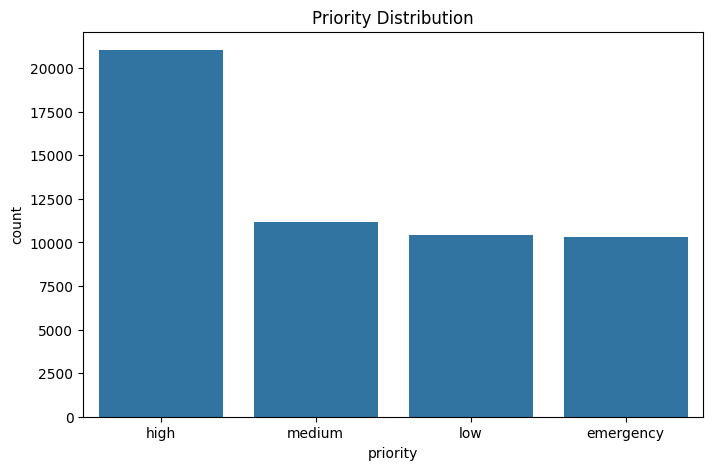

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master_df,

    x="priority"
)

plt.title(
    "Priority Distribution"
)

plt.show()

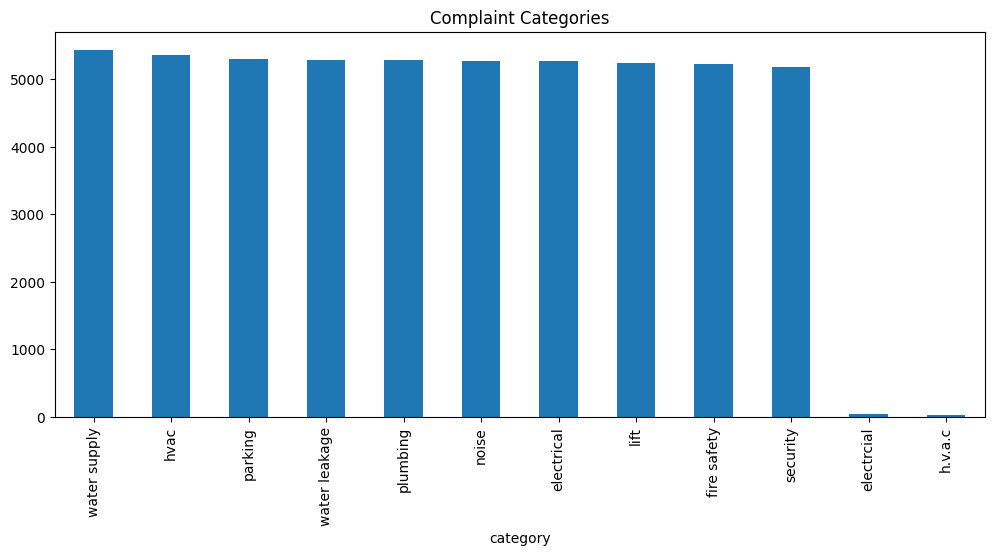

In [29]:
plt.figure(figsize=(12,5))

master_df["category"] \
.value_counts() \
.plot(
    kind="bar"
)

plt.title(
    "Complaint Categories"
)

plt.show()

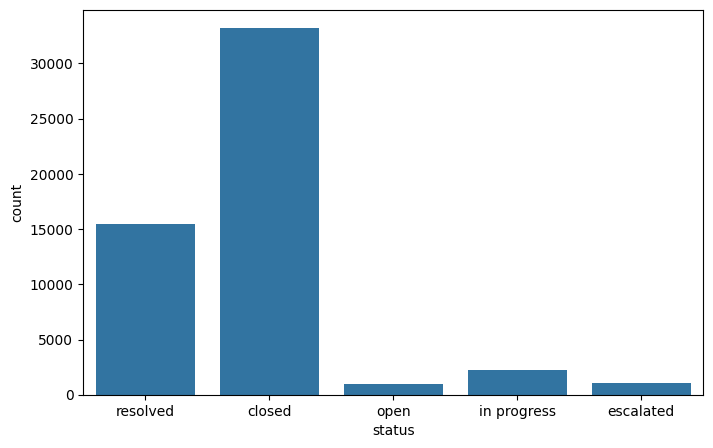

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master_df,

    x="status"
)

plt.show()

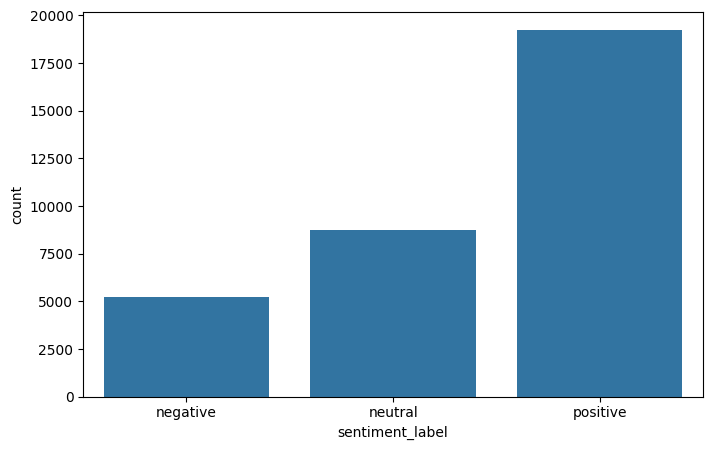

In [31]:
if "sentiment_label" in master_df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(

        data=master_df,

        x="sentiment_label"
    )

    plt.show()

In [32]:
season_df = (

    master_df

    .groupby("season_flag")

    .size()

    .reset_index(
        name="complaints"
    )

)

fig = px.pie(

    season_df,

    names="season_flag",

    values="complaints",

    title="Complaints By Season"
)

fig.show()

In [33]:
asset_df = (

    master_df

    .groupby("asset_category")

    .size()

    .reset_index(
        name="complaints"
    )

)

asset_df = asset_df.sort_values(

    "complaints",

    ascending=False

).head(10)

asset_df

,asset_category,complaints
1,fire alarm,25121
2,generator,5614
4,lift,5577
3,hvac unit,4433
6,water tank,4401
0,cctv,4152
5,water pump,3622


In [34]:
fig = px.bar(

    asset_df,

    x="asset_category",

    y="complaints",

    title="Top Asset Categories"
)

fig.show()

In [35]:
tech_df = (

    master_df

    .groupby(
        "technician_name"
    )

    ["resolution_time_hours"]

    .mean()

    .reset_index()

    .sort_values(
        "resolution_time_hours"
    )

)

tech_df.head(10)

,technician_name,resolution_time_hours
35,neha sharma,7.795245
46,sneha gupta,8.369719
30,neha gupta,8.453744
24,meera iyer,9.562626
17,isha rao,11.823474
4,amit patel,12.380348
20,karthik reddy,13.126316
18,karthik gupta,13.311839
2,amit das,15.266816
19,karthik patel,15.299589


In [36]:
fig = px.bar(

    tech_df.head(10),

    x="technician_name",

    y="resolution_time_hours",

    title="Best Technicians"
)

fig.show()

In [37]:
numeric_df = master_df.select_dtypes(
    include=np.number
)

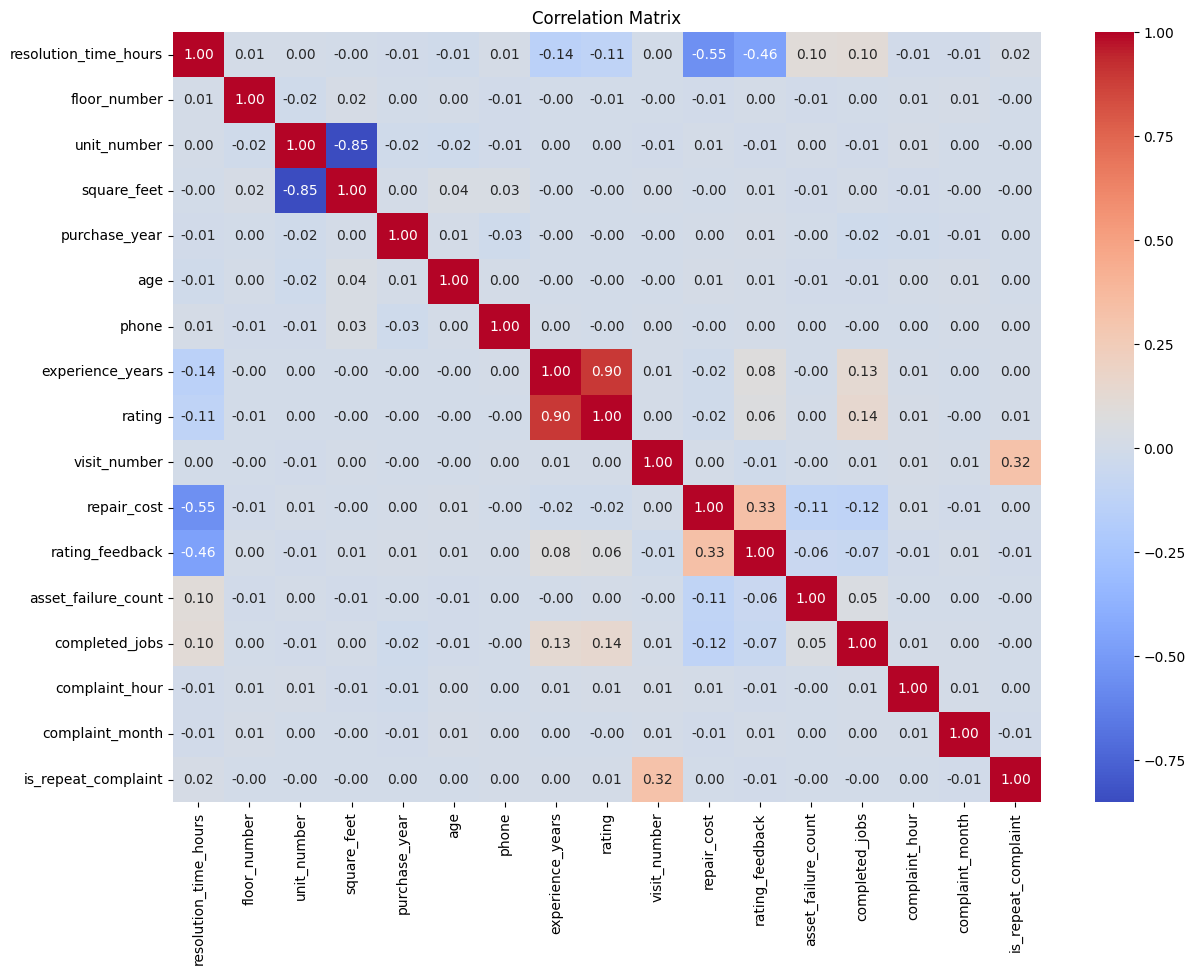

In [39]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",        
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix")
plt.show()

In [40]:
print(
    "Most Common Category:"
)

print(

    master_df["category"]

    .value_counts()

    .head(5)

)

Most Common Category:
category
water supply     5431
hvac             5355
parking          5303
water leakage    5284
plumbing         5282
Name: count, dtype: int64


In [41]:
print(
    "Average Resolution Time"
)

master_df[
    "resolution_time_hours"
].mean()

Average Resolution Time


24.81482917611489

In [42]:
master_df.to_csv(

    "../data/integrated/master_dataset_featured.csv",

    index=False
)

print(
    "Feature Dataset Saved"
)

Feature Dataset Saved
